In [1]:
import argparse
import os
import time
import glog, json

import torch
import torch.multiprocessing as mp
from transformers import AutoModelForCausalLM, AutoTokenizer, LlavaForConditionalGeneration
from transformers.modeling_attn_mask_utils import \
    _prepare_4d_causal_attention_mask

from operator import attrgetter

import sys
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

# std = 0.012528747320175171
if project_root not in sys.path:
    sys.path.append(project_root)
# sys.path.append(os.path.dirname(os.path.abspath(os.path.dirname(__file__))))

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'comp_lm_qtip'))

if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added to path: {project_root}")
import lib.utils as utils
 
from NWC.models import get_model

class Config:
    def __init__(self, **entries):
        self.__dict__.update(entries)
        

def load_comp_model(comp_model_path):
    config = os.path.join(os.path.dirname(comp_model_path), 'config.json')
    with open(config, 'r', encoding='utf-8') as file:
        config = json.load(file)
    config = Config(**config)
    
    shift, scale = torch.empty(()), torch.empty(())
    if config.architecture == 'nwc_ql' and not hasattr(config, "Q"):
        config.Q = 4
    if not hasattr(config, "no_layernorm"):
        config.no_layernorm = False
    

    comp_model = get_model(config.architecture, config, scale=scale, shift=shift)
    comp_model.config = config
    ckpt = torch.load(comp_model_path, weights_only=False)
    try:
        raise
        scale = ckpt["state_dict"]["scale"]
        shift = ckpt["state_dict"]["shift"]
        print('Use train scale and shift')
        print('shift: ', shift, ' scale:', scale)
    except:
        scale, shift  = torch.ones(1), torch.zeros(1)


    comp_model.load_state_dict(ckpt["state_dict"], strict = False)
    # comp_model.scale = scale
    # comp_model.shift = shift
    try: ## scale_cond
        comp_model.scale.copy_(scale)
        comp_model.shift.copy_(shift)
    except:
        comp_model.scale = scale
        comp_model.shift = shift
        pass
    comp_model.eval()
    comp_model.update()

    return comp_model

W0127 12:43:02.498605 963566 warnings.py:109] /opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

W0127 12:43:03.291864 963566 warnings.py:109] /opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(



Added to path: /home/jgryu/workspace/weight_compression/comp_lm_qtip


I0127 12:43:04.427022 963566 utils.py:148] Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
I0127 12:43:04.428057 963566 utils.py:151] Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
I0127 12:43:04.428937 963566 utils.py:164] NumExpr defaulting to 16 threads.
W0127 12:43:10.017139 963566 warnings.py:109] /opt/conda/lib/python3.10/site-packages/compressai/models/video/google.py:353: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @amp.autocast(enabled=False)

Importing from quanto will be deprecated in v4.47. Please install optimum-quanto instrad `pip install optimum-quanto`
W0127 12:43:37.088675 963566 warnings.py:109] /opt/conda/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the 

In [2]:
path = "/home/jgryu/workspace/weight_compression/NWC/checkpoint/nwc_ql/block_seq_ql_random_scaler_meta-llama--Meta-Llama-3-8B__col_1024_gaussian_padding.pt/M16/lmbda300_rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/best_loss_model_loss_5.32101_bpp_5.72603_MSE_0.00289_total_iter_95000.pth.tar"
nwc = load_comp_model(path)

In [3]:
nwc.scale


tensor([1.])

In [4]:
base_model = '/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B'
model = AutoModelForCausalLM.from_pretrained(base_model,
                                                torch_dtype='auto',
                                                low_cpu_mem_usage=True,
                                                local_files_only=True,)


Loading checkpoint shards: 100%|██████████| 7/7 [00:01<00:00,  5.17it/s]


In [5]:
import math

def comp_W(W, H, model,**kwargs):    
    bs = min(W.shape[1], 4096*4096 // W.shape[0])
    (m, n) = W.shape
    glog.info(f'{W.shape}')
    W_hat = torch.zeros_like(W)
    num_pixels = 0
    bpp_loss_sum = 0
    bpp_sum = 0
    codes = []
    
    # row_norm = kwargs.get('row_norm', None)  # (m, 1)
    # col_norm = kwargs.get('col_norm', None)  # (1, n)

    scale_cond = kwargs.get('scale_cond', None)  # (1, n)
    
    qlevel = kwargs.get('qlevel', None)
    qlevel = qlevel.reshape(W.shape[1], ) if qlevel is not None else None
    
    y_in_list = kwargs.get('y_in_list', None)
    
    
    for i,e in enumerate(range(n, 0, -bs)):
        s = max(0, e - bs)

        w = W[:, s:e]        
        
        ql = qlevel[s:e] if qlevel is not None else None
        sc = scale_cond[:, s:e] if scale_cond is not None else None
 
        x_hat, n_pixels, bpp_loss_, out, out_enc, nbits = model_foward_one_batch(w.clone(), model, ql = ql, sc = sc)

        codes.append(out_enc)
        bpp_sum += nbits
        W_hat[:, s:e] = x_hat
        num_pixels += n_pixels
        bpp_loss_sum += bpp_loss_
    
    return {'hatWr': W_hat,
            'bpp_loss_sum': bpp_loss_sum.item(),
            'bpp_loss': bpp_loss_sum.item() / num_pixels,
            'num_pixels': num_pixels,
            'bpp_sum': bpp_sum,
            'bpp': bpp_sum / num_pixels,
            'codes': codes,
            'bpp_loss_for_train': bpp_loss_sum / num_pixels,
            }   
    
def model_foward_one_batch(w, model, **kwargs):
    y_in = kwargs.get('y_in', None)
    mode = kwargs.get('mode', 'init')
    ql = kwargs.get('ql', None)  # (n, )
    (m, n) = w.shape if w is not None else kwargs.get('shape', None)
    
    blks = model.input_size
    # assert (m if args.direction == 'col' else n) % blks == 0
    original_m, original_n = m, n
    pad_len = 0    
    # if args.direction == 'col':
    if 'col' == 'col':
        # Col 방향일 때는 m(행)이 blks의 배수여야 함
        if m % blks != 0:
            pad_len = blks - (m % blks)
            # w shape: (m, n) -> pad bottom rows: (last_dim_left, last_dim_right, 2nd_last_left, 2nd_last_right)
            # (0, 0, 0, pad_len)
            if w is not None:
                w = F.pad(w, (0, 0, 0, pad_len))
            m = m + pad_len  # m 업데이트
    else:
        # Row 방향일 때는 n(열)이 blks의 배수여야 함
        if n % blks != 0:
            pad_len = blks - (n % blks)
            # w shape: (m, n) -> pad right cols
            if w is not None:
                w = F.pad(w, (0, pad_len))
            n = n + pad_len  # n 업데이트
    
    
    sc = kwargs.get('sc', None)  # (1, n)
    sc = sc.repeat(m, 1) if sc is not None else None #(m, n)
    
    if ql is not None:
        ql = ql.reshape(1, n).expand(m//blks, n)
    else:
        ql = torch.full((m//blks, n), 1, dtype=torch.int32, device=w.device)
        # raise
    
    transpose = True
    w = w.T if (w is not None and transpose) else w
    ql = ql.T if (ql is not None and transpose) else ql
    # qm = qm.T if (qm is not None and transpose) else qm
    sc = sc.T if sc is not None and transpose else sc
    
    data = {}
    if w is not None:
        w = w.reshape(1, -1, blks)
    data['weight_block'] = w
    # assert torch.isnan(w).any() == False
    
    if ql is not None:
        data['q_level'] = ql.reshape(1, m*n//blks)
    # if qm is not None:
    #     data['qmap'] = qm.reshape(1, w.shape[1])
    if hasattr(model, 'pe') and model.pe:
        wtype_mapping = {'q': 0, 'k': 1, 'v': 2, 'o': 3, 'gate': 4, 'up': 5, 'down': 6}
        depth = args.layer_idx
        ltype = wtype_mapping[args.layer_name]
        data['depth'] = torch.full((1, 1), depth, dtype=torch.long).to(w.device)
        data['ltype'] = torch.full((1, 1), ltype, dtype=torch.long).to(w.device)
    if sc is not None:
        sc =  sc.reshape(1, -1, blks)       
        if hasattr(model, 'scale_cond') and model.scale_cond:
            assert torch.all(sc == sc[..., :1])
            sc = sc[..., 0] #(1,  m*n//blks)
            assert sc.shape == (1, m*n//blks)
        data['scale_cond'] = sc
        
    num_pixels = m*n
    bpp_loss_sum = torch.tensor(0)
    nbits = 0
    out_enc = None
    out = None
    

    # q_embed = model.quality_embedding(data['q_level']) # (B, -1, encdim)
    # w_hat = model.g_a(w, q_embed)

    out = model(data)
    w_hat = out['x_hat']

    if True:
        # 현재 w_hat은 (n, m) 형태 (padding 포함)
        w_hat = w_hat.reshape(n, m).transpose(0, 1).contiguous()
        # 복원된 w_hat은 (m, n). 여기서 m은 패딩된 크기.
        if pad_len > 0:
            w_hat = w_hat[:original_m, :]
    else:
        w_hat = w_hat.reshape(m, n)
        if pad_len > 0:
            w_hat = w_hat[:, :original_n]

    torch.cuda.empty_cache()
    
    return w_hat, num_pixels, bpp_loss_sum, out, out_enc, nbits

In [33]:
import numpy as np

in_hess_path = '/home/jgryu/workspace/weight_compression/Wparam_dataset/quip_hess/llama3_8b_6144/10_qkv.pt'
# in_hess_path = '/home/jgryu/workspace/weight_compression/Wparam_dataset/quip_hess/llama3_8b_6144/0_up.pt'
H_data = torch.load(in_hess_path, map_location=torch.device('cpu'))
HR = utils.flat_to_sym(H_data['flatH'], H_data['n'])
n_h = H_data['n']
if 'mu' in H_data:
    mu = H_data['mu']
    HR += mu[None, :] * mu[:, None]
    del mu
del H_data
# HR = utils.regularize_H(HR, args.sigma_reg)
HR = utils.regularize_H2(HR, n_h, 0.001)

top = np.array([0.1, 1, 10])
qlevels = [3, 2, 1]
in_norm = torch.diag(HR)
topk = (top * len(in_norm)/100).astype(int)
Qlevel = torch.zeros_like(in_norm, dtype=torch.int32)
_, topk_indices = torch.topk(in_norm, k=topk.sum())
start = 0
for count, value in zip(topk , qlevels):
    indices = topk_indices[start:start + count]
    Qlevel[indices] = value
    start += count

# W  =  model.model.layers[0].self_attn.q_proj.weight
W  =  model.model.layers[10].self_attn.q_proj.weight
# W  =  model.model.layers[0].mlp.up_proj.weight
W = W / W.std(dim = 0, keepdim = True) 
# W  =  torch.randn(4096, 4096)
torch.cuda.empty_cache()
deivce = torch.device('cuda:0')

with torch.no_grad():
    W = W.to(deivce)
    nwc.to(deivce)
    out = comp_W(W, None, nwc, qlevel= Qlevel.to(W.device))
    W_hat = out['hatWr']



W0127 14:32:04.038092 963566 warnings.py:109] /tmp/ipykernel_963566/1955684520.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  H_data = torch.load(in_hess_path, map_loca

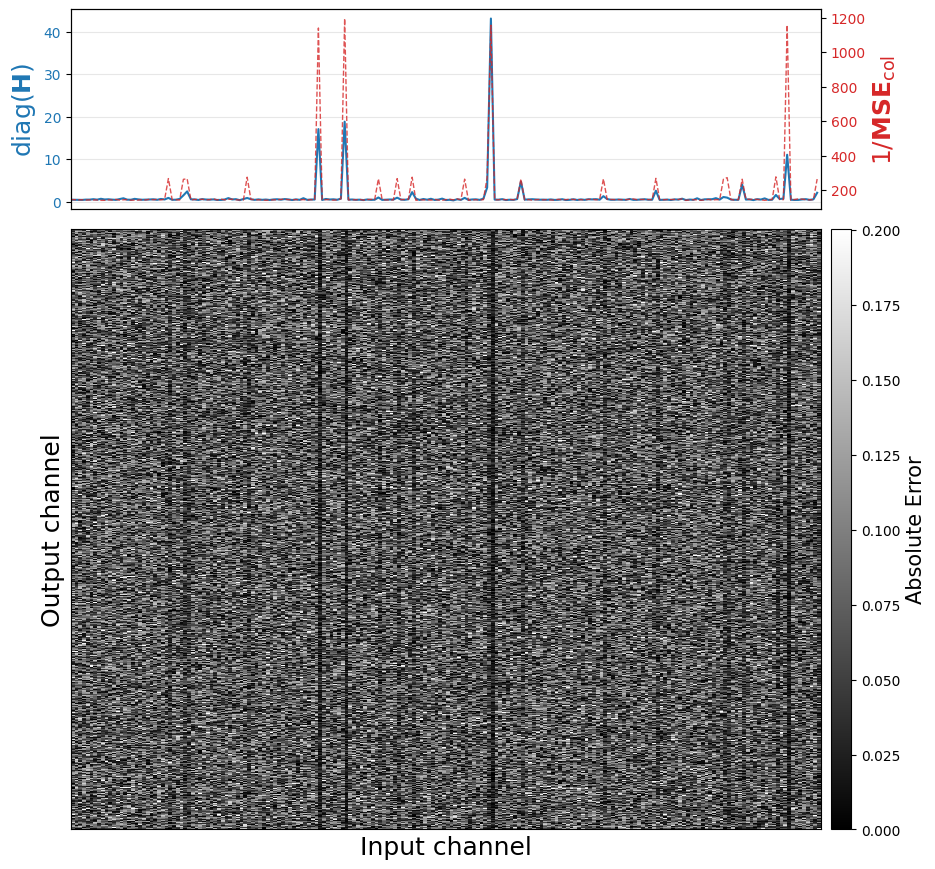

In [42]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# plt.rcParams.update({
#     "font.family": "serif",
#     "mathtext.fontset": "cm",  # Computer Modern 폰트 (논문 표준)
# })
plt.rcdefaults()
def plot_perfect_align_manual(W, W_hat, HR, col_range=None):
    # 1. 데이터 준비
    if col_range is None:
        start, end = 0, W.shape[1]
    else:
        start, end = col_range

    diff = (W - W_hat).abs()
    
    col_mean_error = torch.mean(diff**2, dim=0).cpu().numpy()[start:end]
    col_mean_error = 1/col_mean_error
    row_means = torch.mean(diff, dim=1, keepdim=True)
    # diff_norm = diff / (row_means + 1e-8)
    diff_norm = diff
    diff_norm_np = diff_norm.cpu().float().numpy()[:, start:end]
    
    if HR.dim() == 2:
        h_diag_np = torch.diag(HR)[start:end].cpu().float().numpy()
    else:
        h_diag_np = HR[start:end].cpu().float().numpy()

    # 2. 캔버스 생성 (subplots 아님)
    fig = plt.figure(figsize=(10, 10))

    # =================================================================
    # [핵심] 절대 좌표로 위치 강제 지정 (0.0 ~ 1.0 비율)
    # width 변수를 공유하므로 너비가 다를 수가 없음
    # =================================================================
    left_margin = 0.10   # 왼쪽 여백 (Y축 라벨 공간)
    plot_width  = 0.75   # 그래프 너비 (위/아래 동일)
    
    bottom_h = 0.05      # 하단 그래프 바닥 위치
    height_h = 0.60      # 하단 그래프 높이
    
    gap = 0.02           # 그래프 사이 간격
    
    bottom_t = bottom_h + height_h + gap # 상단 그래프 바닥 위치
    height_t = 0.20      # 상단 그래프 높이

    # 좌표 정의 [left, bottom, width, height]
    rect_top  = [left_margin, bottom_t, plot_width, height_t]
    rect_bot  = [left_margin, bottom_h, plot_width, height_h]
    rect_cbar = [left_margin + plot_width + 0.01, bottom_h, 0.02, height_h] # 컬러바

    # 축 생성
    ax1 = fig.add_axes(rect_top)
    ax2 = fig.add_axes(rect_bot)
    cax = fig.add_axes(rect_cbar)

    # ==========================================
    # [상단 그래프 그리기]
    # ==========================================
    x_axis = np.arange(start, end)
    
    # (1) Hessian (왼쪽 Y축)
    ln1 = ax1.plot(x_axis, h_diag_np, color='tab:blue', linewidth=1.5, label='diag(H)')
    ax1.set_ylabel(r'$\mathrm{diag}(\mathbf{H})$', color='tab:blue', fontsize  = 18)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(start, end) # X축 범위 고정
    ax1.set_xticks([])       # X축 눈금 제거
    
    # (2) Mean Error (오른쪽 Y축 - Twinx)
    ax1_twin = ax1.twinx()
    ln2 = ax1_twin.plot(x_axis, col_mean_error, color='tab:red', linestyle='--', linewidth=1, alpha=0.8, label='Col Mean Error')
    ax1_twin.set_ylabel(r'$1 / \mathbf{MSE}_{\mathrm{col}}$', color='tab:red', fontsize = 18)
    ax1_twin.tick_params(axis='y', labelcolor='tab:red')
    
    # Twin axis는 add_axes로 만든 ax1 위에 겹쳐지므로 위치가 자동 일치함.
    # 단, X축 범위는 명시적으로 맞춰주는 것이 안전함
    ax1_twin.set_xlim(start, end)

    # ==========================================
    # [하단 그래프] Heatmap
    # ==========================================
    mean_err = np.mean(diff_norm_np)
    std_err = np.std(diff_norm_np)
    
    im = ax2.imshow(diff_norm_np, cmap='gray', aspect='auto', interpolation='nearest',
                    extent=[start, end, diff_norm_np.shape[0], 0],
                    vmin=0, vmax=mean_err + 3 * std_err)

    ax2.set_xlim(start, end) # X축 범위 고정
    
    # 요청하신 대로 하단 틱 제거
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xlabel('Input channel', fontsize  = 18)
    ax2.set_ylabel('Output channel', fontsize  = 18)
    
    # 컬러바
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Absolute Error', fontsize = 15)
    # plt.tight_layout(pad=0.3)
    plt.savefig('./plot_encoder_function.pdf', bbox_inches='tight', pad_inches=0.05)
    # plt.savefig('./plot_encoder_function.pdf')
        

    plt.show()
    plt.show()

# 실행
plot_perfect_align_manual(W, W_hat, HR, col_range=(800, 1000))

Analyzing blocks with shape: torch.Size([1048576, 16])
Cumulative Variance: tensor([0.2273, 0.3437, 0.4153, 0.4736, 0.5318, 0.5856, 0.6342, 0.6801, 0.7253,
        0.7691, 0.8108, 0.8511, 0.8901, 0.9280, 0.9654, 1.0000])


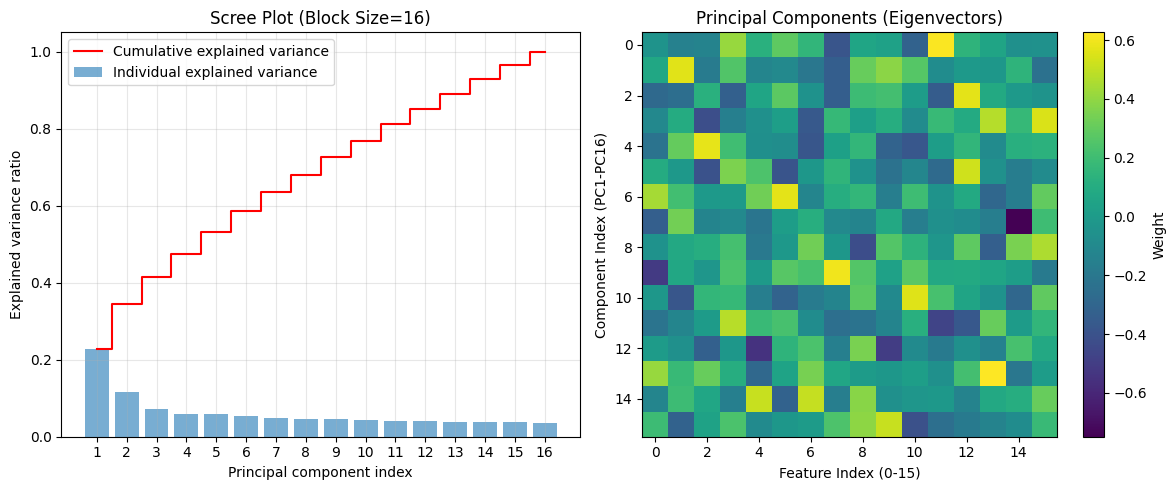

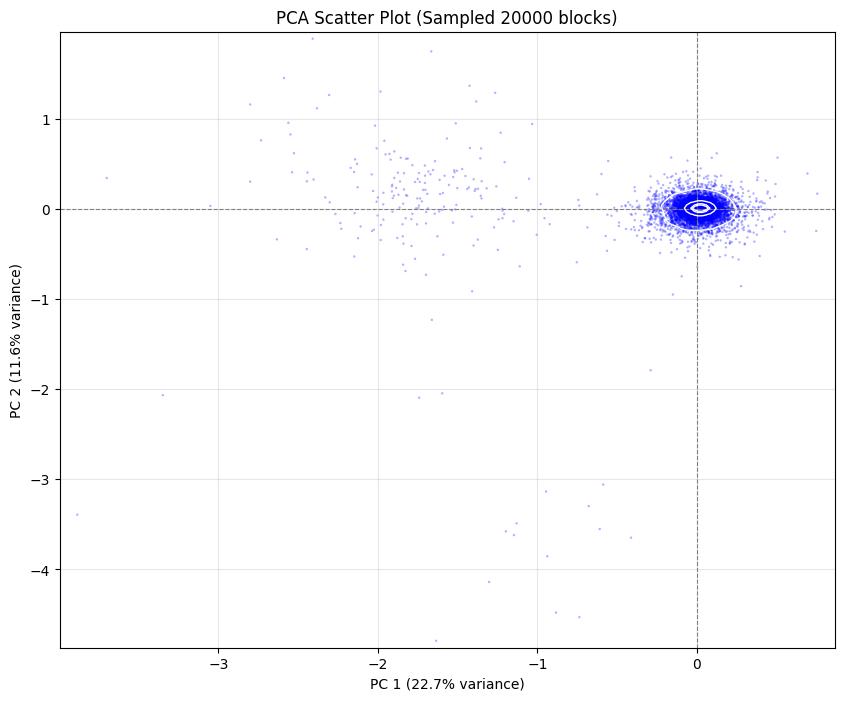

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def analyze_what_blocks_pca(result_dict, block_size=16, device='cuda'):
    """
    comp_W의 결과 딕셔너리를 받아 W_hat에 대해 블록 단위 PCA를 수행합니다.
    """
    # 1. W_hat 추출 및 전처리
    W_hat = result_dict['hatWr']
    
    # device 이동 (연산 속도를 위해 GPU 권장)
    if device == 'cuda' and torch.cuda.is_available():
        W_hat = W_hat.to('cuda')
    
    # 2. Reshape: Transpose 후 (N, block_size) 형태로 변경
    # 모델 forward pass와 동일한 로직: (M, N) -> (N, M) -> (-1, 16)
    # 텐서가 메모리에 연속적이지 않을 수 있으므로 contiguous() 호출
    W_blocks = W_hat.T.reshape(-1, block_size).contiguous()
    
    print(f"Analyzing blocks with shape: {W_blocks.shape}") # 예: (1048576, 16)
    
    # 3. PCA 수행 (SVD 활용)
    # 데이터 중심화 (Centering): 각 차원(16개)별 평균을 뺌
    mean = torch.mean(W_blocks, dim=0)
    centered_data = W_blocks - mean
    
    # SVD 수행: U, S, Vh = svd(X)
    # full_matrices=False로 설정하여 경제적 SVD 수행
    U, S, Vh = torch.linalg.svd(centered_data, full_matrices=False)
    
    # 4. 결과 분석
    # Vh: Principal Components (Eigenvectors), shape (16, 16)
    # S: Singular Values
    
    # 설명된 분산(Explained Variance) 계산
    # Eigenvalues = (S^2) / (n_samples - 1)
    eigenvalues = (S ** 2) / (W_blocks.shape[0] - 1)
    total_variance = eigenvalues.sum()
    explained_variance_ratio = eigenvalues / total_variance
    cumulative_variance = torch.cumsum(explained_variance_ratio, dim=0)
    
    # 결과 반환 (CPU로 이동)
    return {
        'components': Vh.cpu(),
        'singular_values': S.cpu(),
        'explained_variance_ratio': explained_variance_ratio.cpu(),
        'cumulative_variance': cumulative_variance.cpu(),
        'mean': mean.cpu()
    }

def plot_pca_results(pca_results):
    """
    PCA 분석 결과를 시각화합니다.
    """
    evr = pca_results['explained_variance_ratio'].numpy()
    cum_var = pca_results['cumulative_variance'].numpy()
    components = pca_results['components'].numpy()
    
    plt.figure(figsize=(12, 5))
    
    # 1. Scree Plot (설명된 분산 비율)
    plt.subplot(1, 2, 1)
    x = np.arange(1, len(evr) + 1)
    plt.bar(x, evr, alpha=0.6, label='Individual explained variance')
    plt.step(x, cum_var, where='mid', label='Cumulative explained variance', color='red')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal component index')
    plt.title('Scree Plot (Block Size=16)')
    plt.xticks(x)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # 2. Principal Components Heatmap (주성분 시각화)
    # 각 행이 주성분 벡터입니다.
    plt.subplot(1, 2, 2)
    plt.imshow(components, cmap='viridis', aspect='auto')
    plt.colorbar(label='Weight')
    plt.title('Principal Components (Eigenvectors)')
    plt.xlabel('Feature Index (0-15)')
    plt.ylabel('Component Index (PC1-PC16)')
    
    plt.tight_layout()
    plt.show()

import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_scatter(W_hat, pca_stats, block_size=16, num_samples=10000):
    """
    W_hat 블록들을 PC1, PC2 공간에 투영하여 Scatter Plot을 그립니다.
    """
    # 1. 데이터 준비 (GPU -> CPU)
    # W_hat 전처리: Transpose -> Reshape -> Centering
    # (이미 pca_stats에 mean이 계산되어 있으므로 활용)
    W_blocks = W_hat.T.reshape(-1, block_size).contiguous()
    
    # 너무 많으면 샘플링 (Overplotting 방지)
    total_blocks = W_blocks.shape[0]
    if total_blocks > num_samples:
        indices = torch.randperm(total_blocks)[:num_samples]
        samples = W_blocks[indices]
    else:
        samples = W_blocks

    # Centering (PCA 분석 시 구한 평균 사용)
    mean = pca_stats['mean'].to(samples.device)
    centered_samples = samples - mean

    # 2. 투영 (Projection)
    # PC1, PC2 벡터 가져오기 (Eigenvectors)
    # components shape: (16, 16) -> 상위 2개 행이 PC1, PC2
    components = pca_stats['components'].to(samples.device)
    
    # Project: Data(N, 16) @ Vh.T(16, 2) = Scores(N, 2)
    # Vh의 상위 2개 행을 가져와서 Transpose 하여 곱함
    projected_data = torch.matmul(centered_samples, components[:2, :].T).cpu().numpy()

    # 3. 시각화 (Scatter Plot)
    plt.figure(figsize=(10, 8))
    
    # x축: PC1, y축: PC2
    # alpha: 점이 겹쳐도 밀도를 볼 수 있게 투명도 설정
    # s: 점의 크기
    plt.scatter(projected_data[:, 0], projected_data[:, 1], 
                alpha=0.3, s=3, c='blue', edgecolors='none')
    
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    
    plt.title(f'PCA Scatter Plot (Sampled {len(samples)} blocks)')
    plt.xlabel(f'PC 1 ({pca_stats["explained_variance_ratio"][0]:.1%} variance)')
    plt.ylabel(f'PC 2 ({pca_stats["explained_variance_ratio"][1]:.1%} variance)')
    plt.grid(True, alpha=0.3)
    
    # 4. (선택사항) 밀도 등고선 추가 - 데이터가 어디에 집중되었는지 확인
    try:
        import seaborn as sns
        sns.kdeplot(x=projected_data[:, 0], y=projected_data[:, 1], 
                    levels=5, color="w", linewidths=1)
    except ImportError:
        pass # seaborn이 없으면 생략

    plt.show()

pca_stats = analyze_what_blocks_pca(out, block_size=16)

print("Cumulative Variance:", pca_stats['cumulative_variance'])
plot_pca_results(pca_stats)
plot_pca_scatter(out['hatWr'], pca_stats, num_samples=2000nj0)

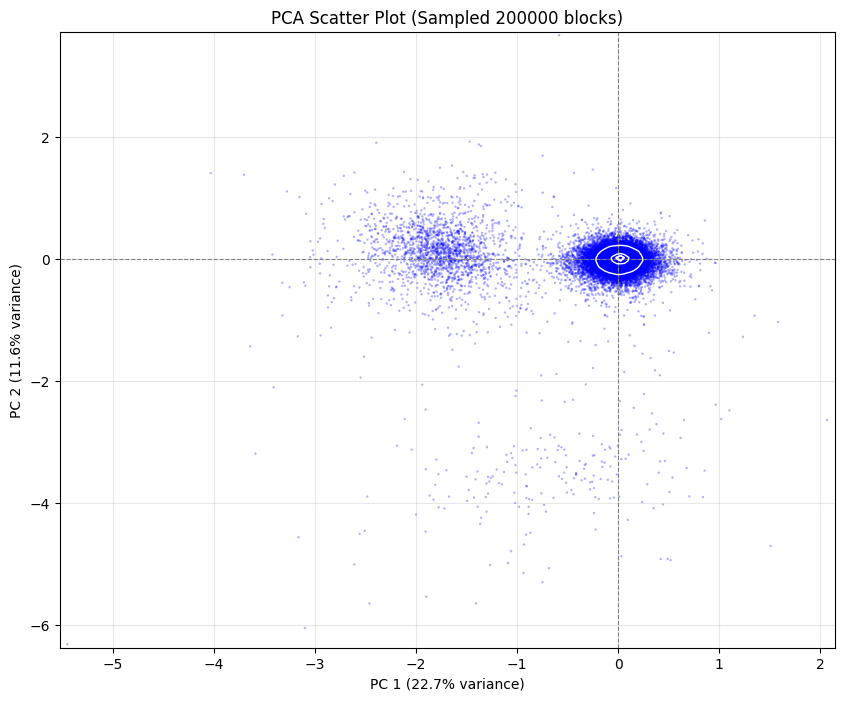

In [9]:
plot_pca_scatter(out['hatWr'], pca_stats, num_samples=200000)


Tensor     | Kurtosis   | Max Sigma  | Outlier(>3σ)   
-------------------------------------------------------
W          | 20.48      | 43.57      | 1.94%
W_hat      | -0.01      | 3.60       | 0.00%
W_fft      | 1.10       | 11.63      | 0.82%
W_had      | 8.08       | 24.92      | 1.77%


I0124 18:10:03.693207 2311188 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
I0124 18:10:29.632838 2311188 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
W0124 18:10:44.302502 2311188 warnings.py:109] /tmp/ipykernel_2311188/1836777563.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(list(data_dict.keys()))



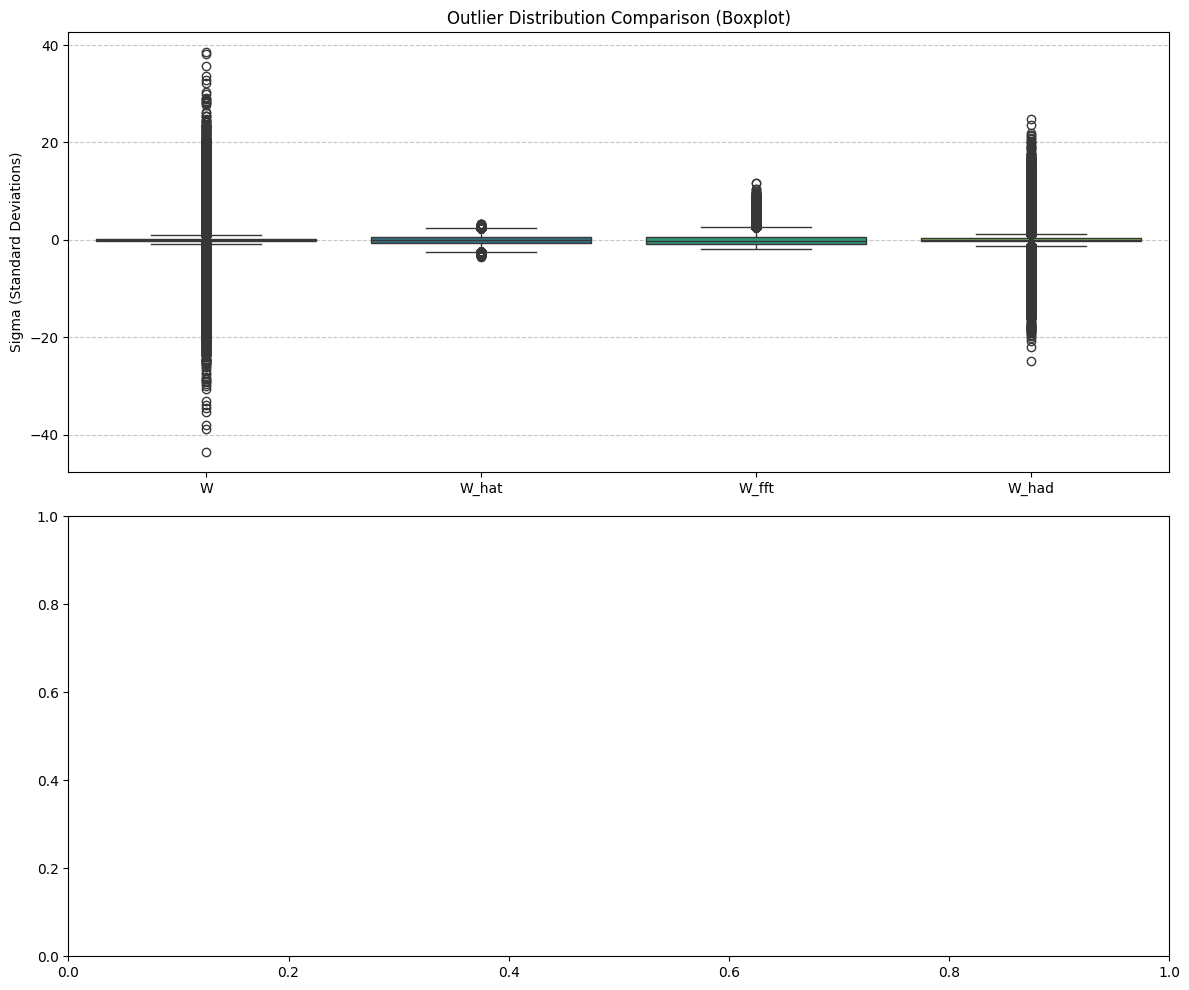

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis
from scipy.linalg import hadamard

# -------------------------------------------------------
# 1. 유틸리티 함수 (변환 및 정규화)
# -------------------------------------------------------

def to_numpy(tensor):
    if hasattr(tensor, 'detach'):
        return tensor.detach().cpu().numpy()
    return tensor

def normalize_zscore(data):
    """평균 0, 표준편차 1로 정규화 (Sigma 단위로 변환)"""
    eps = 1e-8
    return (data - np.mean(data)) / (np.std(data) + eps)

def apply_fft(mat):
    """2D FFT Magnitude 계산"""
    f_transform = np.fft.fft2(mat)
    return np.abs(np.fft.fftshift(f_transform))

def apply_hadamard(mat):
    """Walsh-Hadamard Transform (Zero-padding 적용)"""
    rows, cols = mat.shape
    max_dim = max(rows, cols)
    next_power_of_2 = 2**int(np.ceil(np.log2(max_dim)))
    
    # Padding
    padded = np.zeros((next_power_of_2, next_power_of_2))
    padded[:rows, :cols] = mat
    
    # H * W (행 변환을 통해 값을 섞음)
    H = hadamard(next_power_of_2)
    return H @ padded

# -------------------------------------------------------
# 2. 데이터 준비 (4가지 변수 생성)
# -------------------------------------------------------

# [중요] 사용자의 W, W_hat이 있다고 가정 (없으면 랜덤 생성)
# W = np.random.randn(128, 128) 
# W[0, 0] = 50 # 인위적 이상치 추가
# W_hat = W + np.random.normal(0, 0.5, (128, 128))

# 1) NumPy 변환
w_np = to_numpy(W)
w_hat_np = to_numpy(W_hat)

# 2) 변환 수행 (W_fft, W_had 생성)
w_fft_np = apply_fft(w_np)
w_had_np = apply_hadamard(w_np)

# 3) Flatten & Normalize (모두 1차원 배열 및 Z-Score로 변환)
data_dict = {
    "W": normalize_zscore(w_np.flatten()),
    "W_hat": normalize_zscore(w_hat_np.flatten()),
    "W_fft": normalize_zscore(w_fft_np.flatten()),
    "W_had": normalize_zscore(w_had_np.flatten())
}

# -------------------------------------------------------
# 3. 통계 및 시각화 (4개 동시 비교)
# -------------------------------------------------------

# (1) 통계 테이블 출력
print(f"{'Tensor':<10} | {'Kurtosis':<10} | {'Max Sigma':<10} | {'Outlier(>3σ)':<15}")
print("-" * 55)

stats_list = []
for name, data in data_dict.items():
    kurt = kurtosis(data)
    max_sigma = np.max(np.abs(data))
    outlier_pct = np.sum(np.abs(data) > 3) / len(data) * 100
    
    print(f"{name:<10} | {kurt:<10.2f} | {max_sigma:<10.2f} | {outlier_pct:.2f}%")

# (2) 시각화
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# A. Combined Boxplot (이상치 범위 비교)
sns.boxplot(data=list(data_dict.values()), ax=axes[0], palette="viridis", showfliers=True)
axes[0].set_xticklabels(list(data_dict.keys()))
axes[0].set_title("Outlier Distribution Comparison (Boxplot)")
axes[0].set_ylabel("Sigma (Standard Deviations)")
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)

# B. Combined Histogram (Log Scale - 꼬리 비교)
# colors = ['blue', 'red', 'green', 'purple']
# for i, (name, data) in enumerate(data_dict.items()):
#     sns.histplot(data, element="step", fill=False, stat="density", 
#                  label=name, color=colors[i], alpha=0.8, linewidth=1.5, ax=axes[1])

# axes[1].set_yscale('log') # 로그 스케일로 꼬리 부분 확대
# axes[1].set_title("Density Distribution Comparison (Log Scale)")
# axes[1].set_xlabel("Sigma (Z-Score)")
# axes[1].set_ylabel("Log Density")
# axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
W_hat

Tensor     | Kurtosis   | Max Sigma  | Outlier(>3σ)   
-------------------------------------------------------
Original   | 20.48      | 43.57      | 1.94%
DCT        | 0.46       | 10.54      | 0.50%
Rand_Rot   | 5.42       | 16.77      | 1.86%
Rand_Had   | 5.44       | 16.66      | 1.86%
W_hat      | -0.00      | 2.70       | 0.00%


W1125 10:24:34.625389 96672 warnings.py:109] /tmp/ipykernel_96672/2995308957.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



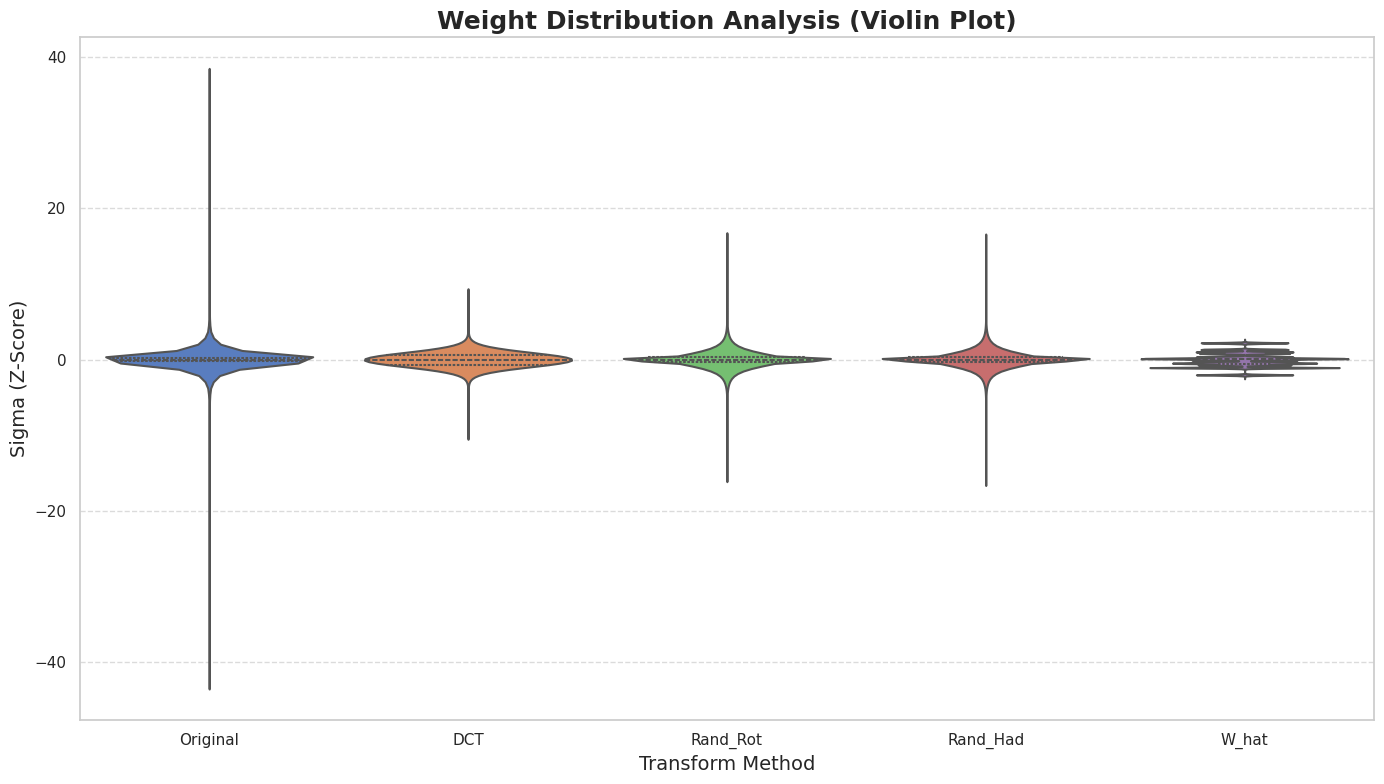

In [12]:
import numpy as np
import pandas as pd  # DataFrame 변환용
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis
from scipy.fftpack import dctn
from scipy.linalg import hadamard

# -------------------------------------------------------
# 1. 유틸리티 및 데이터 생성 (기존과 동일)
# -------------------------------------------------------
def normalize_zscore(data):
    eps = 1e-8
    return (data - np.mean(data)) / (np.std(data) + eps)

def apply_dct(mat):
    return dctn(mat, type=2, norm='ortho')

def apply_random_rotation(mat):
    dim = mat.shape[0]
    H = np.random.randn(dim, dim)
    Q, _ = np.linalg.qr(H) 
    return Q @ mat

def apply_randomized_hadamard(mat):
    rows, cols = mat.shape
    max_dim = max(rows, cols)
    next_power_of_2 = 2**int(np.ceil(np.log2(max_dim)))
    padded = np.zeros((next_power_of_2, next_power_of_2))
    padded[:rows, :cols] = mat
    signs = np.random.choice([-1, 1], size=(next_power_of_2, 1))
    H = hadamard(next_power_of_2)
    return H @ (padded * signs) / np.sqrt(next_power_of_2)


w_np = to_numpy(W)
w_hat_np = to_numpy(W_hat)

data_dict = {
    "Original": normalize_zscore(w_np.flatten()),
    "Rand_Rot": normalize_zscore(apply_random_rotation(w_np).flatten()),
    "Rand_Had": normalize_zscore(apply_randomized_hadamard(w_np).flatten()),
    "DCT": normalize_zscore(apply_dct(w_np).flatten()),
    "NWC_enc": normalize_zscore(w_hat_np.flatten()),
}

# -------------------------------------------------------
# 2. [핵심] Pandas DataFrame으로 변환
# -------------------------------------------------------
# Seaborn 바이올린 플롯은 Long-form 데이터프레임일 때 가장 예쁘게 그려집니다.
df_list = []
for name, data in data_dict.items():
    # 데이터가 너무 많으면 시각화가 느려질 수 있으므로 샘플링 (옵션)
    # sample_data = np.random.choice(data, 20000, replace=False) if len(data) > 20000 else data
    
    temp_df = pd.DataFrame({"Method": name, "Sigma": data})
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# -------------------------------------------------------
# 3. 시각화 (Violin Plot)
# -------------------------------------------------------

# 통계 출력
# (1) 통계 테이블 출력
print(f"{'Tensor':<10} | {'Kurtosis':<10} | {'Max Sigma':<10} | {'Outlier(>3σ)':<15}")
print("-" * 55)
stats_list = []
for name, data in data_dict.items():
    kurt = kurtosis(data)
    max_sigma = np.max(np.abs(data))
    outlier_pct = np.sum(np.abs(data) > 3) / len(data) * 100
    
    print(f"{name:<10} | {kurt:<10.2f} | {max_sigma:<10.2f} | {outlier_pct:.2f}%")

plt.figure(figsize=(14, 8))

# 스타일 설정
sns.set_theme(style="whitegrid")

# 바이올린 플롯 그리기
# inner="quartile": 내부에 박스 플롯 대신 4분위수(25%, 50%, 75%) 선을 그립니다.
# cut=0: 데이터가 존재하는 범위까지만 그립니다. (Outlier 확인에 좋음)
sns.violinplot(
    data=df, 
    x="Method", 
    y="Sigma", 
    palette="muted", 
    inner="quartile", 
    linewidth=1.5,
    cut=0 
)

plt.title("Weight Distribution Analysis (Violin Plot)", fontsize=18, fontweight='bold')
plt.ylabel("Sigma (Z-Score)", fontsize=14)
plt.xlabel("Transform Method", fontsize=14)

# Y축에 그리드 추가 (가독성)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# [옵션] Y축 범위를 제한하여 중심부(Body) 모양을 더 자세히 보고 싶을 때 주석 해제
# plt.ylim(-5, 5) 

plt.tight_layout()
plt.show()